# SymBot Transformer — Disease Classifier + Severity Predictor
Custom self-attention transformer built from scratch in PyTorch.

**Architecture:** Symptom Tokenizer → Self-Attention Encoder (×2) → Dual Head (Disease Classification + Severity Regression)

**Trains on:** 132 symptoms → 41 diseases, with manual backprop visibility via Adam optimizer.

In [1]:
import subprocess
subprocess.run(['pip', 'install', 'torch', 'pandas', 'scikit-learn', 'numpy'], capture_output=True)

CompletedProcess(args=['pip', 'install', 'torch', 'pandas', 'scikit-learn', 'numpy'], returncode=0, stdout=b'Requirement already satisfied: torch in C:\\Users\\alpha\\AppData\\Local\\Programs\\Python\\Python313\\Lib\\site-packages (2.9.1)\r\nRequirement already satisfied: pandas in C:\\Users\\alpha\\AppData\\Local\\Programs\\Python\\Python313\\Lib\\site-packages (2.3.3)\r\nRequirement already satisfied: scikit-learn in C:\\Users\\alpha\\AppData\\Local\\Programs\\Python\\Python313\\Lib\\site-packages (1.8.0)\r\nRequirement already satisfied: numpy in C:\\Users\\alpha\\AppData\\Local\\Programs\\Python\\Python313\\Lib\\site-packages (2.2.6)\r\nRequirement already satisfied: filelock in C:\\Users\\alpha\\AppData\\Local\\Programs\\Python\\Python313\\Lib\\site-packages (from torch) (3.29.0)\r\nRequirement already satisfied: typing-extensions>=4.10.0 in C:\\Users\\alpha\\AppData\\Local\\Programs\\Python\\Python313\\Lib\\site-packages (from torch) (4.15.0)\r\nRequirement already satisfied: sym

In [2]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'✅ Using device: {device}')
if torch.cuda.is_available():
    print(f'   GPU: {torch.cuda.get_device_name(0)}')

✅ Using device: cpu


## 1. Load & Prepare Data

In [3]:
df_main = pd.read_csv('data/dataset.csv')
df_sev  = pd.read_csv('data/Symptom-severity.csv')

# ── Build severity lookup ────────────────────────────────────────
severity_map = {}
for _, row in df_sev.iterrows():
    s = str(row['Symptom']).strip().replace('_', ' ').lower()
    severity_map[s] = int(row['weight'])

# ── Build vocabulary of all 132 symptoms ─────────────────────────
ALL_SYMPTOMS = sorted(severity_map.keys())
SYMPTOM_TO_IDX = {s: i for i, s in enumerate(ALL_SYMPTOMS)}
NUM_SYMPTOMS = len(ALL_SYMPTOMS)

print(f'✅ Vocabulary size: {NUM_SYMPTOMS} symptoms')

✅ Vocabulary size: 132 symptoms


In [4]:
symptom_cols = [c for c in df_main.columns if c.startswith('Symptom_')]

X_rows = []      # multi-hot symptom vectors
y_disease = []   # disease label per row
y_severity = []  # average severity per row

for _, row in df_main.iterrows():
    disease = str(row['Disease']).strip()
    vec = np.zeros(NUM_SYMPTOMS, dtype=np.float32)
    sev_scores = []

    for col in symptom_cols:
        val = str(row[col]).strip()
        if val and val.lower() != 'nan':
            clean = val.replace('_', ' ').strip().lower()
            if clean in SYMPTOM_TO_IDX:
                vec[SYMPTOM_TO_IDX[clean]] = 1.0
                sev_scores.append(severity_map.get(clean, 1))

    avg_sev = np.mean(sev_scores) if sev_scores else 1.0

    X_rows.append(vec)
    y_disease.append(disease)
    y_severity.append(avg_sev)

X = np.stack(X_rows)
y_severity = np.array(y_severity, dtype=np.float32)

le = LabelEncoder()
y_disease_enc = le.fit_transform(y_disease)
NUM_CLASSES = len(le.classes_)

print(f'✅ X shape: {X.shape}')
print(f'✅ Diseases (classes): {NUM_CLASSES}')
print(f'✅ Severity range: {y_severity.min():.2f} – {y_severity.max():.2f}')

✅ X shape: (4920, 132)
✅ Diseases (classes): 41
✅ Severity range: 2.00 – 6.00


In [5]:
X_train, X_val, yd_train, yd_val, ys_train, ys_val = train_test_split(
    X, y_disease_enc, y_severity, test_size=0.15, random_state=42, stratify=y_disease_enc
)

X_train_t  = torch.tensor(X_train, dtype=torch.float32).to(device)
X_val_t    = torch.tensor(X_val, dtype=torch.float32).to(device)
yd_train_t = torch.tensor(yd_train, dtype=torch.long).to(device)
yd_val_t   = torch.tensor(yd_val, dtype=torch.long).to(device)
ys_train_t = torch.tensor(ys_train, dtype=torch.float32).to(device)
ys_val_t   = torch.tensor(ys_val, dtype=torch.float32).to(device)

print(f'✅ Train: {X_train_t.shape[0]} samples | Val: {X_val_t.shape[0]} samples')

✅ Train: 4182 samples | Val: 738 samples


## 2. Build the Transformer
Each symptom is treated as a token. Self-attention learns relationships between symptoms
(e.g. "fever" + "rash" together mean something different than either alone).

In [6]:
class SymptomTokenEmbedding(nn.Module):
    """Turns multi-hot vector into a sequence of token embeddings.
    Present symptoms get their learned embedding; absent ones get a 'PAD' embedding."""
    def __init__(self, num_symptoms, d_model):
        super().__init__()
        self.token_embed = nn.Embedding(num_symptoms, d_model)
        self.present_embed = nn.Parameter(torch.randn(d_model) * 0.02)
        self.absent_embed  = nn.Parameter(torch.randn(d_model) * 0.02)
        self.num_symptoms = num_symptoms
        self.d_model = d_model

    def forward(self, x):
        # x: (batch, num_symptoms) multi-hot
        batch_size = x.shape[0]
        idx = torch.arange(self.num_symptoms, device=x.device).unsqueeze(0).expand(batch_size, -1)
        base = self.token_embed(idx)                          # (batch, num_symptoms, d_model)
        presence = x.unsqueeze(-1)                              # (batch, num_symptoms, 1)
        tokens = base + presence * self.present_embed + (1 - presence) * self.absent_embed
        return tokens


class TransformerEncoderBlock(nn.Module):
    """Single transformer encoder block: Multi-head self-attention + GELU FFN, with
    residual connections and layer norm (standard transformer architecture)."""
    def __init__(self, d_model, num_heads, d_ff, dropout=0.1):
        super().__init__()
        self.attn = nn.MultiheadAttention(d_model, num_heads, dropout=dropout, batch_first=True)
        self.norm1 = nn.LayerNorm(d_model)
        self.ffn = nn.Sequential(
            nn.Linear(d_model, d_ff),
            nn.GELU(),                  # activation function
            nn.Linear(d_ff, d_model),
        )
        self.norm2 = nn.LayerNorm(d_model)
        self.dropout = nn.Dropout(dropout)

    def forward(self, x):
        attn_out, attn_weights = self.attn(x, x, x)
        x = self.norm1(x + self.dropout(attn_out))      # residual + norm
        ffn_out = self.ffn(x)
        x = self.norm2(x + self.dropout(ffn_out))        # residual + norm
        return x, attn_weights


class SymBotTransformer(nn.Module):
    """Full model: Symptom tokens → 2x Transformer Encoder → pooled →
    Disease Classification Head + Severity Regression Head."""
    def __init__(self, num_symptoms, num_classes, d_model=64, num_heads=4, d_ff=128, num_layers=2, dropout=0.1):
        super().__init__()
        self.tokenizer = SymptomTokenEmbedding(num_symptoms, d_model)
        self.encoders = nn.ModuleList([
            TransformerEncoderBlock(d_model, num_heads, d_ff, dropout)
            for _ in range(num_layers)
        ])
        self.pool_proj = nn.Linear(d_model, d_model)

        # Disease classification head
        self.classifier = nn.Sequential(
            nn.Linear(d_model, d_model),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(d_model, num_classes)
        )

        # Severity regression head
        self.severity_head = nn.Sequential(
            nn.Linear(d_model, 32),
            nn.GELU(),
            nn.Linear(32, 1)
        )

    def forward(self, x):
        tokens = self.tokenizer(x)                       # (batch, num_symptoms, d_model)
        attn_maps = []
        for encoder in self.encoders:
            tokens, attn_w = encoder(tokens)
            attn_maps.append(attn_w)

        # Mean pooling weighted by symptom presence (so absent symptoms contribute less)
        presence = x.unsqueeze(-1)                         # (batch, num_symptoms, 1)
        weighted = tokens * (presence + 0.1)                # small base weight so model still sees context
        pooled = weighted.sum(dim=1) / (presence.sum(dim=1) + 1e-6)
        pooled = F.gelu(self.pool_proj(pooled))              # activation function

        disease_logits = self.classifier(pooled)
        severity_pred  = self.severity_head(pooled).squeeze(-1)

        return disease_logits, severity_pred, attn_maps

print('✅ Model architecture defined')

✅ Model architecture defined


## 3. Train with Manual Backprop Loop

In [7]:
model = SymBotTransformer(
    num_symptoms=NUM_SYMPTOMS,
    num_classes=NUM_CLASSES,
    d_model=64,
    num_heads=4,
    d_ff=128,
    num_layers=2,
    dropout=0.1
).to(device)

total_params = sum(p.numel() for p in model.parameters())
print(f'✅ Model created — {total_params:,} parameters')

optimizer = torch.optim.Adam(model.parameters(), lr=1e-3, weight_decay=1e-5)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=10)

classification_loss_fn = nn.CrossEntropyLoss()
severity_loss_fn = nn.MSELoss()

SEVERITY_LOSS_WEIGHT = 0.1   # disease classification matters more

✅ Model created — 88,618 parameters


In [8]:
EPOCHS = 150
history = {'train_loss': [], 'val_loss': [], 'val_acc': []}
best_val_acc = 0

for epoch in range(EPOCHS):
    # ── Training step ────────────────────────────────────────────
    model.train()
    optimizer.zero_grad()

    disease_logits, severity_pred, _ = model(X_train_t)

    loss_cls = classification_loss_fn(disease_logits, yd_train_t)
    loss_sev = severity_loss_fn(severity_pred, ys_train_t)
    loss = loss_cls + SEVERITY_LOSS_WEIGHT * loss_sev

    loss.backward()                 # ← backpropagation happens here
    torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
    optimizer.step()                # ← weight update (gradient descent via Adam)

    # ── Validation step ──────────────────────────────────────────
    model.eval()
    with torch.no_grad():
        val_logits, val_sev_pred, _ = model(X_val_t)
        val_loss_cls = classification_loss_fn(val_logits, yd_val_t)
        val_loss_sev = severity_loss_fn(val_sev_pred, ys_val_t)
        val_loss = val_loss_cls + SEVERITY_LOSS_WEIGHT * val_loss_sev

        val_preds = val_logits.argmax(dim=1)
        val_acc = (val_preds == yd_val_t).float().mean().item()

    scheduler.step(val_loss)

    history['train_loss'].append(loss.item())
    history['val_loss'].append(val_loss.item())
    history['val_acc'].append(val_acc)

    if val_acc > best_val_acc:
        best_val_acc = val_acc
        torch.save({
            'model_state': model.state_dict(),
            'label_encoder_classes': le.classes_,
            'symptom_vocab': ALL_SYMPTOMS,
            'd_model': 64, 'num_heads': 4, 'd_ff': 128, 'num_layers': 2,
        }, 'symbot_transformer.pt')

    if epoch % 10 == 0 or epoch == EPOCHS - 1:
        print(f'Epoch {epoch:3d} | Train Loss: {loss.item():.4f} | Val Loss: {val_loss.item():.4f} | Val Acc: {val_acc*100:.1f}%')

print(f'\n✅ Training complete! Best validation accuracy: {best_val_acc*100:.1f}%')
print(f'✅ Model saved to symbot_transformer.pt')

Epoch   0 | Train Loss: 5.4174 | Val Loss: 5.3341 | Val Acc: 0.3%
Epoch  10 | Train Loss: 3.9934 | Val Loss: 3.9196 | Val Acc: 2.4%
Epoch  20 | Train Loss: 3.8262 | Val Loss: 3.8023 | Val Acc: 2.4%
Epoch  30 | Train Loss: 3.6870 | Val Loss: 3.6631 | Val Acc: 6.6%
Epoch  40 | Train Loss: 3.4168 | Val Loss: 3.3641 | Val Acc: 16.3%
Epoch  50 | Train Loss: 2.9240 | Val Loss: 2.8265 | Val Acc: 36.6%
Epoch  60 | Train Loss: 2.2589 | Val Loss: 2.1245 | Val Acc: 66.9%
Epoch  70 | Train Loss: 1.6221 | Val Loss: 1.4499 | Val Acc: 91.3%
Epoch  80 | Train Loss: 1.0874 | Val Loss: 0.9007 | Val Acc: 99.2%
Epoch  90 | Train Loss: 0.6721 | Val Loss: 0.5213 | Val Acc: 100.0%
Epoch 100 | Train Loss: 0.4159 | Val Loss: 0.2931 | Val Acc: 100.0%
Epoch 110 | Train Loss: 0.2608 | Val Loss: 0.1614 | Val Acc: 100.0%
Epoch 120 | Train Loss: 0.1717 | Val Loss: 0.0952 | Val Acc: 100.0%
Epoch 130 | Train Loss: 0.1161 | Val Loss: 0.0609 | Val Acc: 100.0%
Epoch 140 | Train Loss: 0.0869 | Val Loss: 0.0428 | Val Acc: 

## 4. Visualize Training

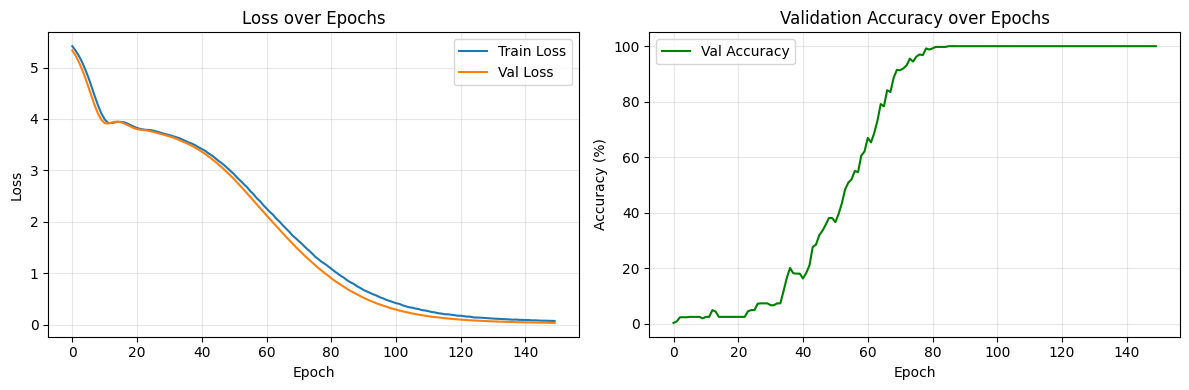

✅ Saved training_curves.png


In [12]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(history['train_loss'], label='Train Loss')
axes[0].plot(history['val_loss'], label='Val Loss')
axes[0].set_title('Loss over Epochs')
axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Loss')
axes[0].legend(); axes[0].grid(alpha=0.3)

axes[1].plot([a*100 for a in history['val_acc']], color='green', label='Val Accuracy')
axes[1].set_title('Validation Accuracy over Epochs')
axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('Accuracy (%)')
axes[1].legend(); axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig('training_curves.png', dpi=120)
plt.show()
print('✅ Saved training_curves.png')

## 5. Inference Helper — Test the Trained Model

In [13]:
def predict_disease(symptom_text_list, model, top_k=3):
    """symptom_text_list: list of symptom strings (already cleaned, lowercase, space-separated)"""
    vec = np.zeros(NUM_SYMPTOMS, dtype=np.float32)
    matched = []
    for s in symptom_text_list:
        s_clean = s.strip().lower()
        if s_clean in SYMPTOM_TO_IDX:
            vec[SYMPTOM_TO_IDX[s_clean]] = 1.0
            matched.append(s_clean)

    x = torch.tensor(vec, dtype=torch.float32).unsqueeze(0).to(device)

    model.eval()
    with torch.no_grad():
        logits, severity, attn_maps = model(x)
        probs = F.softmax(logits, dim=1).squeeze(0)
        top_probs, top_idx = probs.topk(top_k)

    results = []
    for p, i in zip(top_probs.cpu().numpy(), top_idx.cpu().numpy()):
        results.append((le.classes_[i], float(p)))

    return {
        'matched_symptoms': matched,
        'predictions': results,
        'severity_score': round(float(severity.item()), 2)
    }

# ── Test it ──────────────────────────────────────────────────────
test_symptoms = ['itching', 'skin rash', 'fever']
result = predict_disease(test_symptoms, model)

print(f"Matched symptoms: {result['matched_symptoms']}")
print(f"Severity score: {result['severity_score']} / 7\n")
print('Top predictions:')
for disease, prob in result['predictions']:
    print(f'  {disease:35s} {prob*100:.1f}%')

Matched symptoms: ['itching', 'skin rash']
Severity score: 3.64 / 7

Top predictions:
  Fungal infection                    98.8%
  Drug Reaction                       0.9%
  Acne                                0.2%
